---
# Phase 1 · Environment & ingestion

### 1.1 Install Arabic NLP libraries

In [1]:
import sys, subprocess

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                    "--break-system-packages", *pkgs], check=False)

_pip("pyarabic", "nltk", "datasets", "pyarrow", "huggingface_hub")

USE_CAMEL = True
try:
    import camel_tools  # noqa: F401
except ImportError:
    print("camel-tools not present — attempting install...")
    _pip("camel-tools")
    try:
        import camel_tools  # noqa: F401
    except ImportError:
        USE_CAMEL = False
        print("camel-tools still unavailable — f046 will use pyarabic fallback.")

import nltk
for resource in ["stopwords", "punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"corpora/{resource}" if resource == "stopwords"
                       else f"tokenizers/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)

print("USE_CAMEL =", USE_CAMEL)

USE_CAMEL = True


### 1.2 Imports + Spark session

In [2]:
import os, re, json, time, glob, math, shutil
from dataclasses import dataclass
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (HashingTF, IDF, VectorAssembler, StandardScaler)
from pyspark.ml.classification import (LogisticRegression, NaiveBayes,
                                       RandomForestClassifier, LinearSVC,
                                       LogisticRegressionModel,
                                       NaiveBayesModel,
                                       RandomForestClassificationModel,
                                       LinearSVCModel)
from pyspark.ml.evaluation import (MulticlassClassificationEvaluator,
                                   BinaryClassificationEvaluator)

import pyarabic.araby as araby
from nltk.corpus import stopwords as nltk_stopwords

matplotlib.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                            "axes.spines.top": False,
                            "axes.spines.right": False})

spark = (SparkSession.builder
         .appName("ArabicAIDetect_F023_F046")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/04 05:56:58 WARN Utils: Your hostname, localhost.localdomain, resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/05/04 05:56:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/04 05:56:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/04 05:57:00 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


### 1.3 Project layout

In [3]:
@dataclass
class ProjectPaths:
    root: str = os.path.abspath("./arabic_ai_detection_f023_f046")

    @property
    def raw(self):        return os.path.join(self.root, "data", "raw")
    @property
    def processed(self):  return os.path.join(self.root, "data", "processed")
    @property
    def models(self):     return os.path.join(self.root, "models")
    @property
    def figures(self):    return os.path.join(self.root, "reports", "figures")
    @property
    def stream_in(self):  return os.path.join(self.root, "stream", "incoming")
    @property
    def stream_out(self): return os.path.join(self.root, "stream", "predictions")
    @property
    def checkpoint(self): return os.path.join(self.root, "stream", "checkpoint")

    def ensure(self):
        for p in [self.raw, self.processed, self.models, self.figures,
                  self.stream_in, self.stream_out, self.checkpoint]:
            os.makedirs(p, exist_ok=True)

PATHS = ProjectPaths()
PATHS.ensure()
print(PATHS.root)

/home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046


### 1.4 Download the Hugging Face dataset

Loaded as a single full dataset (no `name=` parameter — that one fails for
this repo). Splits are persisted as separate CSVs in `data/raw/`.

In [4]:
from datasets import load_dataset

HF_TOKEN = os.environ.get("HF_TOKEN", None)
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

# Load the entire dataset in one go
dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print("Dataset splits:", list(dataset.keys()))
for split_name, split_data in dataset.items():
    print(f"  {split_name}: {len(split_data):,} rows | columns: {split_data.column_names}")

/home/ahmed/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset splits: ['by_polishing', 'from_title', 'from_title_and_content']
  by_polishing: 2,851 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title: 2,963 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title_and_content: 2,574 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']


In [5]:
class HFLoader:
    """Tiny wrapper around the HF dataset object — caches each split to its own CSV."""

    AI_COLS = ("allam_generated_abstract", "jais_generated_abstract",
               "llama_generated_abstract", "openai_generated_abstract")

    def __init__(self, target_dir: str, ds):
        self.target_dir = target_dir
        self.ds         = ds

    def fetch_all(self):
        """Save each split to CSV. Returns [(split_name, csv_path), ...]."""
        out = []
        for split_name, split_data in self.ds.items():
            csv_path = os.path.join(self.target_dir,
                                    f"arabic_abstracts_{split_name}.csv")
            if os.path.exists(csv_path):
                print(f"  [cache] {split_name}: {csv_path}")
            else:
                print(f"  [save]  {split_name}: {csv_path}")
                split_data.to_pandas().to_csv(csv_path, index=False,
                                              encoding="utf-8-sig")
            out.append((split_name, csv_path))
        return out

    def melt(self, csv_path: str, source_name: str) -> pd.DataFrame:
        df = pd.read_csv(csv_path, encoding="utf-8-sig")
        rows = []
        for _, r in df.iterrows():
            orig = r.get("original_abstract")
            if isinstance(orig, str) and orig.strip():
                rows.append((orig, 0, "human", source_name))
            for col in self.AI_COLS:
                v = r.get(col)
                if isinstance(v, str) and v.strip():
                    rows.append((v, 1, col.replace("_generated_abstract",""),
                                 source_name))
        return pd.DataFrame(rows, columns=["text","label","model","source"])

loader  = HFLoader(PATHS.raw, dataset)
csvs    = loader.fetch_all()
long_pd = pd.concat([loader.melt(p, n) for n, p in csvs], ignore_index=True)
print(f"\nTotal samples (long-format): {len(long_pd):,}")
long_pd.sample(3, random_state=1)

  [save]  by_polishing: /home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046/data/raw/arabic_abstracts_by_polishing.csv
  [save]  from_title: /home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046/data/raw/arabic_abstracts_from_title.csv
  [save]  from_title_and_content: /home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046/data/raw/arabic_abstracts_from_title_and_content.csv

Total samples (long-format): 41,940


,text,label,model,source
4733,يسعى هذا البحث إلى دراسة أسباب استئناف أوامر م...,1,llama,by_polishing
4808,تهدف هذه الدراسة إلى دراسة دور المراقب المالي ...,1,llama,by_polishing
5055,سنحاول من خلال هذه الدراسة العلمية والتاريخية ...,0,human,by_polishing


In [6]:
schema = T.StructType([
    T.StructField("text",   T.StringType(), False),
    T.StructField("label",  T.IntegerType(), False),
    T.StructField("model",  T.StringType(), False),
    T.StructField("source", T.StringType(), False),
])
df_raw = spark.createDataFrame(long_pd, schema=schema).cache()
print("Total rows:", df_raw.count())
df_raw.groupBy("label").agg(F.count("*").alias("n")).show()

/home/ahmed/.local/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Cannot convert pyarrow.lib.ChunkedArray to pyarrow.lib.Array
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/05/04 05:57:41 WARN TaskSetManager: Stage 0 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.
26/05/04 05:57:45 WARN TaskSetManager: Stage 1 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Total rows: 41940


26/05/04 05:57:47 WARN TaskSetManager: Stage 4 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.
[Stage 4:>                                                          (0 + 4) / 4]

+-----+-----+
|label|    n|
+-----+-----+
|    1|33552|
|    0| 8388|
+-----+-----+



---
# Phase 2 · Distributed cleaning, storage & EDA

## 2.1 Arabic preprocessor — `pyarabic` + `nltk`

In [7]:
AR_STOPWORDS = set(nltk_stopwords.words("arabic"))
print(f"NLTK Arabic stopwords loaded: {len(AR_STOPWORDS)} words")
SW_BC = spark.sparkContext.broadcast(AR_STOPWORDS)


class ArabicPreprocessor:
    """Wraps pyarabic + nltk and exposes Spark UDFs."""

    @staticmethod
    def _normalize(text):
        if text is None:
            return None
        t = araby.strip_tashkeel(text)
        t = araby.strip_tatweel(t)
        t = araby.normalize_hamza(t)
        t = araby.normalize_alef(t)
        t = araby.normalize_ligature(t)
        t = re.sub(r"[^\u0600-\u06FF\sA-Za-z0-9\.\,\!\?\:\;\n]", " ", t)
        t = re.sub(r"[ \t]+", " ", t).strip()
        return t

    @staticmethod
    def _tokens(text):
        if not text:
            return []
        toks = araby.tokenize(text)
        sw = SW_BC.value
        return [w for w in toks if len(w) > 1 and w not in sw and not w.isspace()]

    @classmethod
    def normalize_udf(cls):
        return F.udf(cls._normalize, T.StringType())

    @classmethod
    def tokens_udf(cls):
        return F.udf(cls._tokens, T.ArrayType(T.StringType()))


norm_u   = ArabicPreprocessor.normalize_udf()
tokens_u = ArabicPreprocessor.tokens_udf()

df_clean = (df_raw
    .withColumn("clean_text_columns", norm_u("text"))
    .withColumn("tokens",             tokens_u("clean_text_columns"))
    .withColumn("n_tokens",           F.size("tokens"))
    .filter(F.col("n_tokens") >= 5)).cache()

print("Clean rows:", df_clean.count())
df_clean.select("label","n_tokens","clean_text_columns").show(2, truncate=80)

NLTK Arabic stopwords loaded: 701 words


26/05/04 05:58:58 WARN TaskSetManager: Stage 7 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.
26/05/04 05:59:45 WARN TaskSetManager: Stage 8 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Clean rows: 41936
+-----+--------+--------------------------------------------------------------------------------+
|label|n_tokens|                                                              clean_text_columns|
+-----+--------+--------------------------------------------------------------------------------+
|    0|      95|كثيرا ما ارتبطت المصادر التاريخية في الءندلس خاصة منها كتب التراجم والفهرسات ...|
|    1|      62|يتناول هذا البحث موضوع التعليم بين النساء الءندلسيات من خلال دراسة المصادر ال...|
+-----+--------+--------------------------------------------------------------------------------+
only showing top 2 rows


26/05/04 05:59:46 WARN TaskSetManager: Stage 11 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.


## 2.2 Persist as Parquet

In [8]:
parquet_dir = os.path.join(PATHS.processed, "abstracts.parquet")
(df_clean.select("text","clean_text_columns","tokens","n_tokens",
                 "label","model","source")
         .write.mode("overwrite").parquet(parquet_dir))

df_proc = spark.read.parquet(parquet_dir).cache()
print("Reload OK · row count:", df_proc.count())

26/05/04 06:03:56 WARN TaskSetManager: Stage 12 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.
[Stage 14:=============================>                            (2 + 2) / 4]

Reload OK · row count: 41936


## 2.3 EDA — donut + KDE-density + violin + heatmap

In [9]:
class EDAPlots:
    """Bag of plotting helpers with a shared palette."""
    PALETTE = {"human":"#264653", "ai":"#E76F51"}

    @staticmethod
    def _save(fig, name):
        fig.savefig(os.path.join(PATHS.figures, name),
                    dpi=120, bbox_inches="tight")

    @classmethod
    def class_donut(cls, label_pd):
        fig, ax = plt.subplots(figsize=(5,5))
        sizes = label_pd.sort_values("label")["count"].values
        ax.pie(sizes, labels=["Human","AI"], autopct="%1.1f%%",
               colors=[cls.PALETTE["human"], cls.PALETTE["ai"]],
               wedgeprops=dict(width=0.45, edgecolor="white"))
        ax.set_title("Class Composition")
        cls._save(fig, "class_donut.png")
        plt.show()

    @classmethod
    def density(cls, df_pd, col, title, xlabel):
        fig, ax = plt.subplots(figsize=(8, 4))
        for lbl, key in [(0,"human"),(1,"ai")]:
            vals = df_pd.loc[df_pd.label==lbl, col].dropna().values
            if len(vals) < 2: continue
            xs = np.linspace(vals.min(), vals.max(), 200)
            bw = 1.06 * vals.std() * len(vals) ** (-1/5) or 1.0
            ys = np.zeros_like(xs)
            for v in vals:
                ys += np.exp(-0.5 * ((xs - v)/bw)**2)
            ys = ys / (len(vals) * bw * math.sqrt(2*math.pi))
            ax.fill_between(xs, ys, alpha=0.45, color=cls.PALETTE[key],
                            label="Human" if lbl==0 else "AI")
            ax.plot(xs, ys, color=cls.PALETTE[key], lw=1.2)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("Density")
        ax.legend()
        cls._save(fig, f"density_{col}.png")
        plt.show()

    @classmethod
    def violin(cls, df_pd, col, ylabel):
        fig, ax = plt.subplots(figsize=(6,4))
        data = [df_pd.loc[df_pd.label==0, col].dropna().values,
                df_pd.loc[df_pd.label==1, col].dropna().values]
        parts = ax.violinplot(data, showmeans=True, showmedians=False)
        for pc, key in zip(parts["bodies"], ["human","ai"]):
            pc.set_facecolor(cls.PALETTE[key]); pc.set_alpha(0.65)
        ax.set_xticks([1,2]); ax.set_xticklabels(["Human","AI"])
        ax.set_ylabel(ylabel); ax.set_title(f"Violin — {col}")
        cls._save(fig, f"violin_{col}.png")
        plt.show()

    @classmethod
    def heatmap(cls, corr_df, title):
        fig, ax = plt.subplots(figsize=(6,5))
        im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr_df.columns)))
        ax.set_yticks(range(len(corr_df.index)))
        ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
        ax.set_yticklabels(corr_df.index)
        for i in range(corr_df.shape[0]):
            for j in range(corr_df.shape[1]):
                ax.text(j, i, f"{corr_df.values[i,j]:.2f}",
                        ha="center", va="center",
                        color="white" if abs(corr_df.values[i,j])>0.5 else "black",
                        fontsize=8)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.04)
        cls._save(fig, "corr_heatmap.png")
        plt.show()

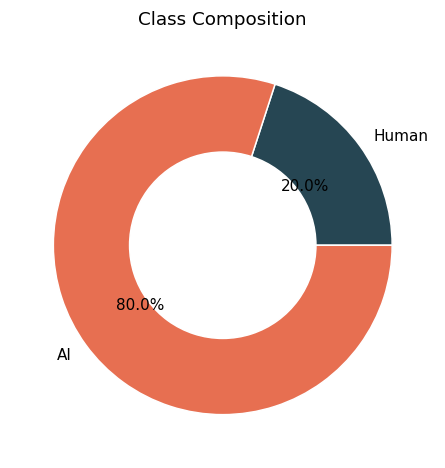

In [10]:
label_pd = df_proc.groupBy("label").count().toPandas()
EDAPlots.class_donut(label_pd)

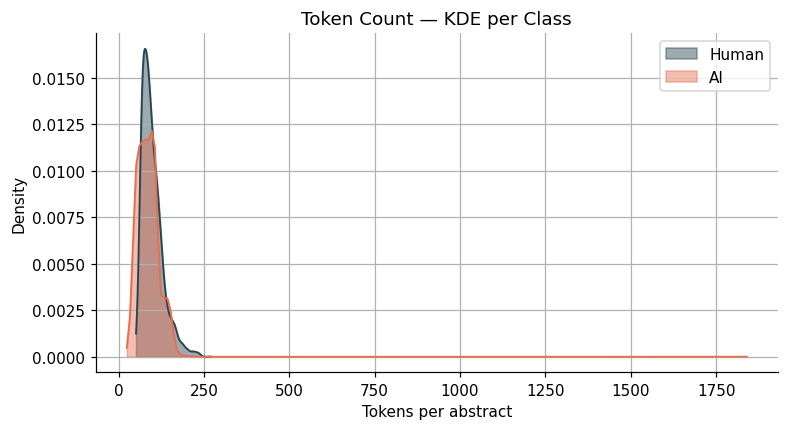

In [11]:
sample_pd = df_proc.select("label","n_tokens").sample(False, 0.5, seed=3).toPandas()
EDAPlots.density(sample_pd, "n_tokens",
                 "Token Count — KDE per Class", "Tokens per abstract")

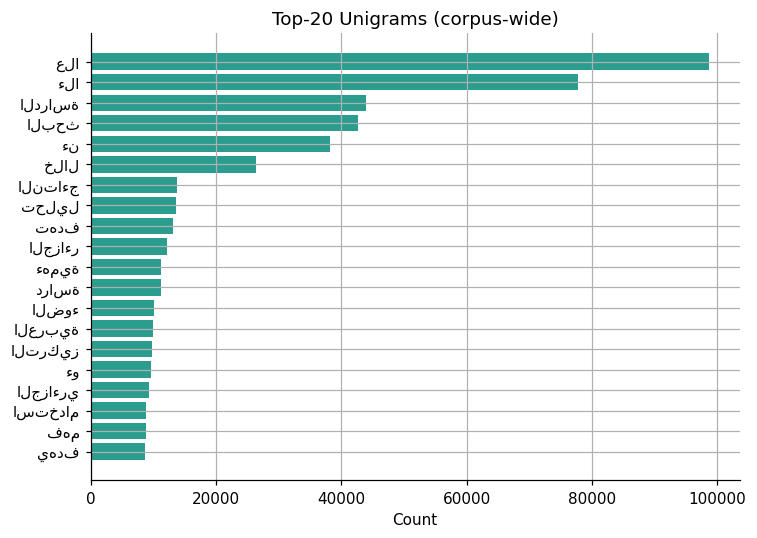

In [12]:
top20 = (df_proc
    .select(F.explode("tokens").alias("w"))
    .groupBy("w").count().orderBy(F.desc("count"))
    .limit(20).toPandas())

fig, ax = plt.subplots(figsize=(7,5))
ax.barh(top20["w"][::-1], top20["count"][::-1], color="#2A9D8F")
ax.set_title("Top-20 Unigrams (corpus-wide)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PATHS.figures, "top_unigrams.png"), dpi=120)
plt.show()

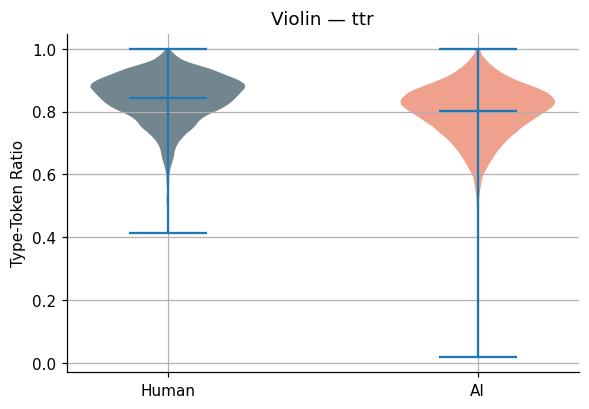

In [13]:
ttr_pd = (df_proc
    .withColumn("uniq", F.size(F.array_distinct("tokens")))
    .withColumn("ttr",  F.col("uniq") / F.col("n_tokens"))
    .select("label","ttr").toPandas())
EDAPlots.violin(ttr_pd, "ttr", "Type-Token Ratio")

---
# Phase 3 · Feature engineering & batch modeling

## 3.1 Stylometric features f023 and f046

In [14]:
clean_text_columns = "clean_text_columns"
feature_name_f023  = f'{clean_text_columns}_f023_avg_syllables_per_word'
feature_name_f046  = f'{clean_text_columns}_f046_num_nouns'

print("Feature column names:")
print(" ", feature_name_f023)
print(" ", feature_name_f046)

Feature column names:
  clean_text_columns_f023_avg_syllables_per_word
  clean_text_columns_f046_num_nouns


### f023 — average syllables per word (pyarabic long/short vowels)

In [15]:
_LONG_VOWELS  = set(araby.LONG_VOWELS) if hasattr(araby, "LONG_VOWELS") \
                else set("اوي")
_SHORT_VOWELS = set(araby.TASHKEEL) if hasattr(araby, "TASHKEEL") \
                else set("\u064B\u064C\u064D\u064E\u064F\u0650\u0652")

def _syllables_in_word(w, long_v=_LONG_VOWELS, short_v=_SHORT_VOWELS):
    """One syllable = one vowel cluster. Un-vocalized cluster → 1."""
    if not w:
        return 0
    n = 0
    in_vowel = False
    for ch in w:
        is_v = (ch in long_v) or (ch in short_v)
        if is_v and not in_vowel:
            n += 1
            in_vowel = True
        elif not is_v:
            in_vowel = False
    return max(n, 1)

def _avg_syllables(words):
    """f023 — mean syllables per word."""
    if not words:
        return 0.0
    total_syls = sum(_syllables_in_word(w) for w in words)
    return float(total_syls) / float(len(words))

f023_udf = F.udf(lambda ws: _avg_syllables(ws), T.DoubleType())

### f046 — noun count (camel-tools POS; falls back to pyarabic heuristic)

In [16]:
_CAMEL_TAGGER = None
if USE_CAMEL:
    try:
        from camel_tools.tagger.default import DefaultTagger
        from camel_tools.disambig.mle import MLEDisambiguator

        _DISAMB  = MLEDisambiguator.pretrained()
        _CAMEL_TAGGER = DefaultTagger(_DISAMB, "pos")
        print("camel-tools POS tagger ready.")
    except Exception as e:
        print(f"camel-tools setup failed ({e}) — using pyarabic fallback.")
        USE_CAMEL = False

_AL_PREFIX   = "ال"
_NOUN_SUFFIX = ("ة","ات","ون","ين","ية","ياً","يا","ها","هم","هن")
_COMMON_VERBS = frozenset("""
    قال يقول قام يقوم ذهب يذهب جاء يأتي كتب يكتب رأى يرى وجد يجد
    أصبح يصبح صار يصير ظل يظل أعطى يعطي شاهد يشاهد سمع يسمع أكل
    يأكل شرب يشرب نام ينام ركض يركض أحب يحب كره يكره عمل يعمل
    فعل يفعل ترك يترك بدأ يبدأ انتهى ينتهي أنشأ ينشئ بنى يبني
""".split())

def _looks_like_noun_heuristic(w):
    if not w or len(w) < 3:                  return False
    if w in _COMMON_VERBS:                   return False
    if w.startswith(_AL_PREFIX) and len(w) > 3: return True
    if w.endswith(_NOUN_SUFFIX):             return True
    if len(w) == 3:                          return True
    return False

def _count_nouns(words):
    """f046 — number of noun-like tokens (camel-tools or heuristic)."""
    if not words:
        return 0
    if USE_CAMEL and _CAMEL_TAGGER is not None:
        try:
            tags = _CAMEL_TAGGER.tag(list(words))
            return sum(1 for t in tags if t and t.lower().startswith("noun"))
        except Exception:
            pass
    return sum(1 for w in words if _looks_like_noun_heuristic(w))

f046_udf = F.udf(lambda ws: _count_nouns(ws), T.IntegerType())

camel-tools setup failed ([Errno 2] No such file or directory: '/home/ahmed/.camel_tools/data/morphology_db/calima-msa-r13/morphology.db') — using pyarabic fallback.


In [17]:
df_feat = (df_proc
   .withColumn(feature_name_f023, f023_udf(F.col("tokens")))
   .withColumn(feature_name_f046, f046_udf(F.col("tokens")))).cache()

df_feat.select("label", "n_tokens",
               feature_name_f023, feature_name_f046).show(5)

[Stage 27:>                                                         (0 + 1) / 1]

+-----+--------+----------------------------------------------+---------------------------------+
|label|n_tokens|clean_text_columns_f023_avg_syllables_per_word|clean_text_columns_f046_num_nouns|
+-----+--------+----------------------------------------------+---------------------------------+
|    0|     101|                            1.6435643564356435|                               62|
|    1|     116|                            1.4655172413793103|                               75|
|    1|     148|                            1.6418918918918919|                               96|
|    1|      78|                            1.4871794871794872|                               54|
|    1|      99|                             1.494949494949495|                               69|
+-----+--------+----------------------------------------------+---------------------------------+
only showing top 5 rows


**EDA on engineered features**

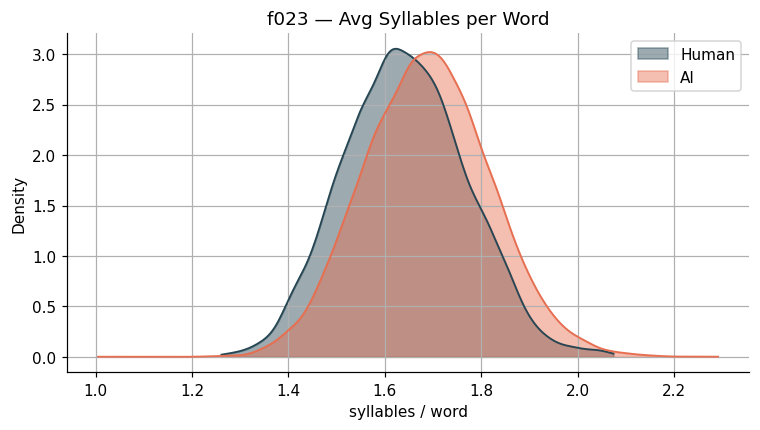

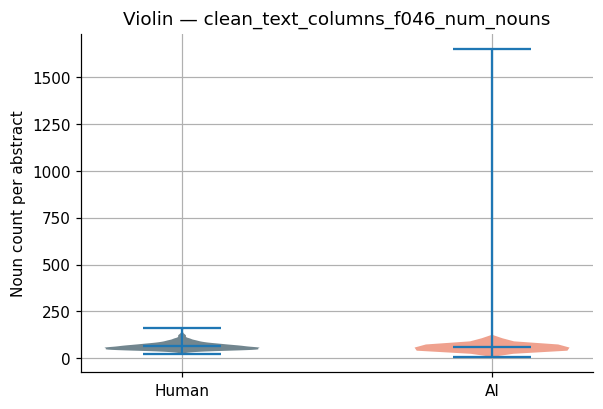

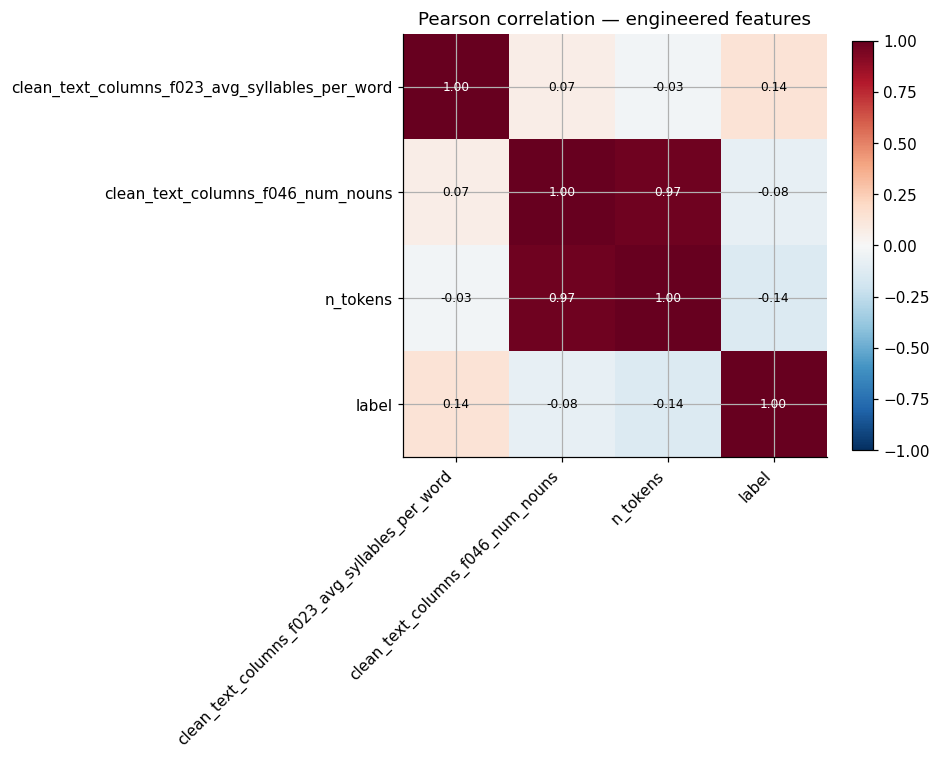

In [19]:
feat_pd = df_feat.select("label", feature_name_f023,
                               feature_name_f046, "n_tokens").toPandas()

EDAPlots.density(feat_pd, feature_name_f023,
                 "f023 — Avg Syllables per Word", "syllables / word")
EDAPlots.violin(feat_pd, feature_name_f046, "Noun count per abstract")

corr = feat_pd[[feature_name_f023, feature_name_f046,
                "n_tokens","label"]].corr()
EDAPlots.heatmap(corr, "Pearson correlation — engineered features")

## 3.2 TF-IDF + stylo (Spark MLlib)

In [20]:
class FeaturePipelineBuilder:
    def __init__(self, tf_dim: int = 4096):
        self.tf_dim = tf_dim

    def build(self) -> Pipeline:
        tf       = HashingTF(inputCol="tokens", outputCol="tf",
                             numFeatures=self.tf_dim)
        idf      = IDF(inputCol="tf", outputCol="tfidf")
        stylo_va = VectorAssembler(
            inputCols=[feature_name_f023, feature_name_f046, "n_tokens"],
            outputCol="stylo_raw")
        scaler   = StandardScaler(inputCol="stylo_raw", outputCol="stylo",
                                  withMean=False, withStd=True)
        merge    = VectorAssembler(inputCols=["tfidf","stylo"],
                                   outputCol="features")
        return Pipeline(stages=[tf, idf, stylo_va, scaler, merge])

prep_pipeline = FeaturePipelineBuilder(tf_dim=4096).build().fit(df_feat)
df_ready      = prep_pipeline.transform(df_feat).select("features","label").cache()
df_ready.show(2, truncate=60)

[Stage 36:>                                                         (0 + 1) / 1]

+------------------------------------------------------------+-----+
|                                                    features|label|
+------------------------------------------------------------+-----+
|(4099,[6,151,183,216,218,371,385,525,642,710,786,826,835,...|    0|
|(4099,[174,183,218,311,317,543,576,648,793,820,835,874,92...|    1|
+------------------------------------------------------------+-----+
only showing top 2 rows


## 3.3 Train / val / test (70 / 15 / 15)

In [21]:
train_df, val_df, test_df = df_ready.randomSplit([0.70, 0.15, 0.15], seed=2026)
print(f"train={train_df.count():,}  val={val_df.count():,}  test={test_df.count():,}")

train=29,345  val=6,430  test=6,161


## 3.4 + 3.5 Model arena

In [22]:
class ModelArena:
    """Trains, evaluates and ranks a small zoo of Spark MLlib classifiers."""

    def __init__(self, train, val):
        self.train, self.val = train, val
        self.results = {}
        self.fitted  = {}

    def _eval(self, fitted):
        preds = fitted.transform(self.val)
        acc = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(preds)
        f1  = MulticlassClassificationEvaluator(metricName="f1").evaluate(preds)
        try:
            auc = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(preds)
        except Exception:
            auc = float("nan")
        return {"acc":acc, "f1":f1, "auc":auc}

    def add(self, name, estimator):
        t0 = time.time()
        m  = estimator.fit(self.train)
        scores = self._eval(m)
        scores["train_sec"] = round(time.time() - t0, 2)
        self.results[name]  = scores
        self.fitted[name]   = m
        print(f"{name:14s}  acc={scores['acc']:.4f}  f1={scores['f1']:.4f}  "
              f"auc={scores['auc']:.4f}  ({scores['train_sec']}s)")

    def best(self, key="f1"):
        name = max(self.results, key=lambda k: self.results[k][key])
        return name, self.fitted[name]

arena = ModelArena(train_df, val_df)
arena.add("NaiveBayes",   NaiveBayes(smoothing=1.0, modelType="multinomial"))
arena.add("LogReg",       LogisticRegression(maxIter=30, regParam=0.01))
arena.add("RandomForest", RandomForestClassifier(numTrees=80, maxDepth=10, seed=2026))
arena.add("LinearSVC",    LinearSVC(maxIter=30, regParam=0.05))

26/05/04 06:08:55 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


NaiveBayes      acc=0.9087  f1=0.9137  auc=0.7275  (4.78s)


LogReg          acc=0.9802  f1=0.9804  auc=0.9955  (11.05s)


26/05/04 06:09:26 WARN DAGScheduler: Broadcasting large task binary with size 1096.0 KiB
26/05/04 06:09:29 WARN DAGScheduler: Broadcasting large task binary with size 1381.8 KiB
26/05/04 06:09:32 WARN DAGScheduler: Broadcasting large task binary with size 1752.6 KiB
26/05/04 06:09:35 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/04 06:09:38 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/05/04 06:09:41 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/05/04 06:09:46 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/05/04 06:09:48 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/05/04 06:09:49 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
                                                                                

RandomForest    acc=0.8123  f1=0.7396  auc=0.9872  (41.76s)


LinearSVC       acc=0.9750  f1=0.9751  auc=0.9946  (12.03s)


### Held-out test

Winner on validation: LogReg
TEST · LogReg: acc=0.9825 · f1=0.9826 · auc=0.9961
prediction   0.0   1.0
label                 
0           1201    35
1             73  4852


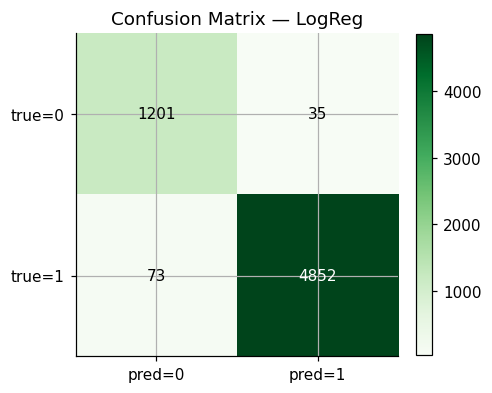

In [23]:
best_name, best_model = arena.best("f1")
print("Winner on validation:", best_name)

test_preds = best_model.transform(test_df)
acc = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(test_preds)
f1  = MulticlassClassificationEvaluator(metricName="f1").evaluate(test_preds)
try:
    auc = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(test_preds)
except Exception:
    auc = float("nan")
print(f"TEST · {best_name}: acc={acc:.4f} · f1={f1:.4f} · auc={auc:.4f}")

cm = (test_preds.groupBy("label","prediction").count().toPandas()
      .pivot(index="label", columns="prediction", values="count")
      .fillna(0).astype(int))
print(cm)

fig, ax = plt.subplots(figsize=(4.5,4))
im = ax.imshow(cm.values, cmap="Greens")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["pred=0","pred=1"]); ax.set_yticklabels(["true=0","true=1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm.values[i,j], ha="center", va="center",
                color="white" if cm.values[i,j]>cm.values.max()/2 else "black")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout()
plt.savefig(os.path.join(PATHS.figures, "confmat.png"), dpi=120)
plt.show()

### Persist pipeline + winner

In [24]:
prep_path = os.path.join(PATHS.models, "prep_pipeline")
clf_path  = os.path.join(PATHS.models, f"clf_{best_name}")
shutil.rmtree(prep_path, ignore_errors=True)
shutil.rmtree(clf_path,  ignore_errors=True)
prep_pipeline.write().overwrite().save(prep_path)
best_model.write().overwrite().save(clf_path)
print("Saved →", prep_path, "and", clf_path)

Saved → /home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046/models/prep_pipeline and /home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046/models/clf_LogReg


---
# Phase 4 · Stream processing & benchmarking

## 4.1 Producer

In [25]:
sample = df_raw.sample(False, 0.005, seed=9).limit(20).toPandas()
for f_old in glob.glob(os.path.join(PATHS.stream_in, "*.json")):
    os.remove(f_old)
for i, r in sample.iterrows():
    with open(os.path.join(PATHS.stream_in, f"abs_{i:03d}.json"),
              "w", encoding="utf-8") as fh:
        json.dump({"text": r["text"], "label": int(r["label"])},
                  fh, ensure_ascii=False)
print(f"Wrote {len(sample)} JSON records to {PATHS.stream_in}")

26/05/04 06:10:47 WARN TaskSetManager: Stage 363 contains a task of very large size (13336 KiB). The maximum recommended task size is 1000 KiB.


Wrote 20 JSON records to /home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046/stream/incoming


## 4.2 Consumer — Spark Structured Streaming

In [26]:
prep_re = PipelineModel.load(prep_path)
clf_cls = {"NaiveBayes":   NaiveBayesModel,
           "LogReg":       LogisticRegressionModel,
           "RandomForest": RandomForestClassificationModel,
           "LinearSVC":    LinearSVCModel}[best_name]
clf_re  = clf_cls.load(clf_path)

stream_schema = T.StructType([
    T.StructField("text",  T.StringType()),
    T.StructField("label", T.IntegerType()),
])

raw_stream = (spark.readStream
              .schema(stream_schema)
              .option("maxFilesPerTrigger", 5)
              .json(PATHS.stream_in))

prepped = (raw_stream
   .withColumn("clean_text_columns", norm_u("text"))
   .withColumn("tokens",             tokens_u("clean_text_columns"))
   .withColumn("n_tokens",           F.size("tokens"))
   .filter(F.col("n_tokens") >= 5)
   .withColumn(feature_name_f023, f023_udf(F.col("tokens")))
   .withColumn(feature_name_f046, f046_udf(F.col("tokens"))))

vectorized  = prep_re.transform(prepped)
predictions = clf_re.transform(vectorized).select("text","label","prediction")

q = (predictions.writeStream
       .outputMode("append")
       .format("json")
       .option("path", PATHS.stream_out)
       .option("checkpointLocation", PATHS.checkpoint)
       .trigger(processingTime="3 seconds")
       .start())

print("Streaming query is live...")
q.awaitTermination(20)
q.stop()
print("Streaming query stopped.")

26/05/04 06:10:54 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Streaming query is live...


Streaming query stopped.


26/05/04 06:11:14 WARN DAGScheduler: Failed to cancel job group a7109247-4579-4aa7-8504-1e6ba9b11830. Cannot find active jobs for it.
26/05/04 06:11:14 WARN DAGScheduler: Failed to cancel job group a7109247-4579-4aa7-8504-1e6ba9b11830. Cannot find active jobs for it.


In [27]:
pred_files = glob.glob(os.path.join(PATHS.stream_out, "*.json"))
print(f"{len(pred_files)} JSON parts written")

if pred_files:
    sdf = spark.read.json(pred_files)
    sdf.show(5, truncate=70)
    sp  = sdf.select("label","prediction").toPandas()
    print(f"Streaming-mode accuracy on simulated batch: "
          f"{(sp.label==sp.prediction).mean():.4f}")

12 JSON parts written
+-----+----------+----------------------------------------------------------------------+
|label|prediction|                                                                  text|
+-----+----------+----------------------------------------------------------------------+
|    1|       1.0|تهدف هذه الدراسة إلى استكشاف دور الأوقاف في تعزيز الخدمات الاجتماعي...|
|    1|       1.0|يتناول البحث الدور المحوري الذي لعبته الدولة العثمانية في إنقاذ مسل...|
|    1|       1.0|محمد الأمين العمودي السوفي، الشاعر الشهيد والصحفي البارز، يمثل رمزً...|
|    1|       0.0|أثر اكتشاف النار على تنمية ثقافات مجتمعات ما قبل التاريخ بشكل يشابه...|
|    1|       1.0|في سياق الثورة التحريرية الجزائرية، لعبت المرأة الجزائرية دوراً حيو...|
+-----+----------+----------------------------------------------------------------------+
only showing top 5 rows
Streaming-mode accuracy on simulated batch: 0.9500


## 4.3 Scalability sweep

   partitions  seconds
0           2    0.365
1           4    0.237
2           8    0.189
3          16    0.214


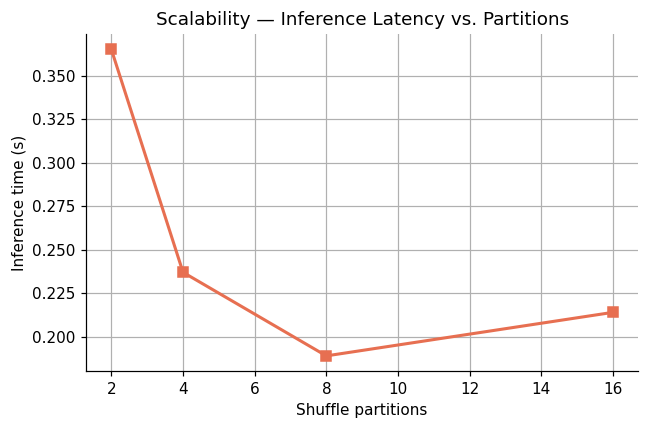

In [28]:
bench = []
for parts in [2, 4, 8, 16]:
    spark.conf.set("spark.sql.shuffle.partitions", parts)
    t0 = time.time()
    _ = best_model.transform(test_df).count()
    bench.append((parts, round(time.time() - t0, 3)))

bench_df = pd.DataFrame(bench, columns=["partitions","seconds"])
print(bench_df)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(bench_df["partitions"], bench_df["seconds"],
        marker="s", lw=2, color="#E76F51")
ax.set_xlabel("Shuffle partitions"); ax.set_ylabel("Inference time (s)")
ax.set_title("Scalability — Inference Latency vs. Partitions")
plt.tight_layout()
plt.savefig(os.path.join(PATHS.figures, "scalability.png"), dpi=120)
plt.show()

---
# Phase 5 · Analysis & reporting

In [29]:
summary_df = (pd.DataFrame(arena.results).T
               .reset_index().rename(columns={"index":"model"})
               .round(4)
               .sort_values("f1", ascending=False))
print(summary_df.to_string(index=False))

       model    acc     f1    auc  train_sec
      LogReg 0.9802 0.9804 0.9955      11.05
   LinearSVC 0.9750 0.9751 0.9946      12.03
  NaiveBayes 0.9087 0.9137 0.7275       4.78
RandomForest 0.8123 0.7396 0.9872      41.76


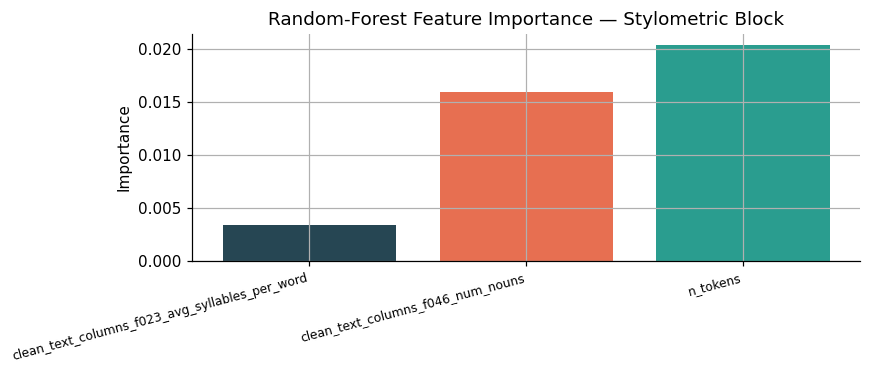

{'clean_text_columns_f023_avg_syllables_per_word': 0.00341, 'clean_text_columns_f046_num_nouns': 0.01591, 'n_tokens': 0.02037}


In [30]:
if "RandomForest" in arena.fitted:
    rf  = arena.fitted["RandomForest"]
    imp = rf.featureImportances.toArray()
    stylo_imp = imp[-3:]
    labels    = [feature_name_f023, feature_name_f046, "n_tokens"]
    fig, ax   = plt.subplots(figsize=(8, 3.5))
    ax.bar(range(len(labels)), stylo_imp,
           color=["#264653","#E76F51","#2A9D8F"])
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=8)
    ax.set_ylabel("Importance")
    ax.set_title("Random-Forest Feature Importance — Stylometric Block")
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS.figures, "importance.png"), dpi=120)
    plt.show()
    print(dict(zip(labels, [round(float(x),5) for x in stylo_imp])))

In [31]:
spark.stop()
print("Done. Artifacts under:", PATHS.root)

Done. Artifacts under: /home/ahmed/Downloads/AI_Detection_Project/arabic_ai_detection_f023_f046
